# NFL Combine Draft Position Predictor
### Analytics Capstone — Guy Schultz

This notebook investigates whether NFL Combine athletic measurables can predict draft outcomes. Two research questions drive the analysis:

1. **Can combine measurables predict where a player will be drafted?** — regression on overall pick number (`draft_ovr`)
2. **Can combine measurables predict whether a player will be drafted at all?** — binary classification (`is_drafted`)

**Data source:** `nflreadpy`the official Python port of the nflverse data ecosystem, maintained by the nflverse team. Covers combine classes 2000–2025.

---
## Section 1 — Data Acquisition & Pipeline

The data pipeline pulls from `nflreadpy`, merges, cleans, and engineers features, then saves the result to CSV. All subsequent sections load from that file


### 1.1 — Package Installation

All packages required for the project are installed in a single cell at the top of the notebook so dependencies are visible and configured before any code runs.


In [1]:
!pip install nflreadpy scikit-learn xgboost imbalanced-learn seaborn --quiet


### 1.2 — Imports

All libraries are imported here. Centralising imports at the top avoids NameErrors later and makes the project's dependencies explicit at a glance.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nflreadpy as nfl

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier
from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print("All packages imported successfully.")
print(f"pandas {pd.__version__} | numpy {np.__version__}")


All packages imported successfully.
pandas 2.3.3 | numpy 2.3.5


### 1.3 — Data Acquisition

Two datasets are sourced from `nflreadpy` covering combine classes 2000–2025:

- **`load_combine()`** — one row per combine attendee with athletic measurements and draft outcome columns already attached
- **`load_draft_picks()`** — one row per drafted player, joined to retrieve player age at draft time which the combine table does not include

`nflreadpy` returns Polars DataFrames which are converted to pandas using `.to_pandas()`

In [3]:
YEARS = list(range(2000, 2026))


combine_raw = nfl.load_combine(seasons=YEARS).to_pandas()
print(f"  Combine: {len(combine_raw):,} rows x {combine_raw.shape[1]} columns")

draft_raw = nfl.load_draft_picks(seasons=YEARS).to_pandas()
print(f"  Draft picks: {len(draft_raw):,} rows x {draft_raw.shape[1]} columns")


  Combine: 8,649 rows x 18 columns
  Draft picks: 6,644 rows x 36 columns


### 1.4 — Merge & Deduplicate

The two tables are joined on the shared Pro Football Reference player ID (`pfr_id`) and draft year to bring in player age. 

A left join is used to retain all combine rows including undrafted players.

The draft picks table has multiple rows per player ID in some seasons, causing row multiplication. Deduplicating on `player_name` and `season` resolves the issue before any cleaning or feature engineering.


In [4]:
draft_join = draft_raw.rename(columns={
    'pfr_player_id': 'pfr_id',
    'season':        'draft_year',
    'age':           'age_at_draft',
    'college':       'dp_college',
})[['pfr_id', 'draft_year', 'age_at_draft', 'dp_college']]

df = combine_raw.merge(
    draft_join, how='left',
    left_on=['pfr_id', 'draft_year'],
    right_on=['pfr_id', 'draft_year']
)
print(f"After merge: {len(df):,} rows")

pre = len(df)
df = df.drop_duplicates(subset=['player_name', 'season'])
print(f"After deduplication: {len(df):,} rows")


After merge: 13,016 rows
After deduplication: 8,639 rows


### 1.5 — Data Cleaning

Seven cleaning steps are applied in sequence:

1. **Height conversion** — from string ie. `"6-2"`to a numeric `height_inches` value
2. **Retain undrafted players** — `is_drafted` flag is added (1 = drafted, 0 = undrafted). `draft_ovr` stays NaN for undrafted players since there is no pick number to assign
3. **Column rename** — for readability ie. `wt` to `weight`, `school` to `college`
4. **Type casting** — target columns cast to numeric
5. **Remove rows missing both height and weight** — these cannot contribute to size-based engineered features
6. **Pick range validation** — `draft_ovr` values outside 1–270 are data errors and removed
7. **Safety deduplication** — a final pass to catch any remaining exact duplicates


In [5]:
df_clean = df.copy()

# 1. Parse height string to numeric inches
def parse_height(ht_str):
    try:
        parts = str(ht_str).split('-')
        if len(parts) == 2:
            return int(parts[0]) * 12 + int(parts[1])
    except (ValueError, AttributeError):
        pass
    return np.nan

df_clean['height_inches'] = df_clean['ht'].apply(parse_height)
print(f"Height parsed. Nulls: {df_clean['height_inches'].isna().sum()}")

# 2. Flag undrafted players 
df_clean['is_drafted'] = df_clean['draft_ovr'].notna().astype(int)
df_clean['draft_round'] = pd.to_numeric(df_clean['draft_round'], errors='coerce')
df_clean['draft_round'] = df_clean['draft_round'].fillna(8).astype('Int64')
print(f"Drafted: {df_clean['is_drafted'].sum():,} | Undrafted: {(df_clean['is_drafted']==0).sum():,}")

# 3. Rename columns
df_clean = df_clean.rename(columns={'wt': 'weight', 'school': 'college'})

# 4. Cast to numeric
df_clean['draft_ovr'] = pd.to_numeric(df_clean['draft_ovr'], errors='coerce')
df_clean['weight']    = pd.to_numeric(df_clean['weight'], errors='coerce')

# 5. Remove rows missing both height and weight
pre = len(df_clean)
df_clean = df_clean[~(df_clean['height_inches'].isna() & df_clean['weight'].isna())].copy()
print(f"Removed {pre - len(df_clean):,} rows missing both height and weight")

# 6. Validate pick range
pre = len(df_clean)
invalid = df_clean['draft_ovr'].notna() & ((df_clean['draft_ovr'] < 1) | (df_clean['draft_ovr'] > 270))
df_clean = df_clean[~invalid].copy()
print(f"Removed {pre - len(df_clean):,} out-of-range pick numbers")

# 7. Safety dedup
pre = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['player_name', 'season'])
print(f"Safety dedup removed {pre - len(df_clean):,} rows")
print(f"\nFinal shape after cleaning: {df_clean.shape}")


Height parsed. Nulls: 29
Drafted: 5,548 | Undrafted: 3,091
Removed 24 rows missing both height and weight
Removed 0 out-of-range pick numbers
Safety dedup removed 0 rows

Final shape after cleaning: (8615, 22)


### 1.6 — Feature Engineering

Five composite athletic scores are derived from the raw data columns. Each composite combines related measurements into a single, more informative signal.

| Feature | Formula | Rationale |
|---------|---------|-----------|
| `speed_score` | `(weight × 200) / forty⁴` | The Football Outsiders weight-adjusted speed metric. Rewards fast *and* heavy players equally — a 250lb linebacker running 4.5 seconds is considerably more impressive than a 170lb cornerback running the same time. |
| `burst_score` | `vertical + (broad_jump / 12)` | Explosiveness test composite.Higher score is better.
| `agility_score` | `cone + shuttle` | Sum of both agility drill times. Lower values indicate greater agility. |
| `bmi` | `(weight / height_inches²) × 703` | Standard Body Mass Index adapted for imperial units. |
| `size_score` | `weight × height_inches` | A single composite capturing mass and frame size.



In [6]:
df_feat = df_clean.copy()

# Athletic composite scores
df_feat['speed_score'] = np.where(
    df_feat['forty'].notna() & df_feat['weight'].notna() & (df_feat['forty'] > 0),
    (df_feat['weight'] * 200) / (df_feat['forty'] ** 4), np.nan)

df_feat['burst_score'] = np.where(
    df_feat['vertical'].notna() & df_feat['broad_jump'].notna(),
    df_feat['vertical'] + (df_feat['broad_jump'] / 12),
    np.where(df_feat['vertical'].notna(), df_feat['vertical'], np.nan))

df_feat['agility_score'] = np.where(
    df_feat['cone'].notna() & df_feat['shuttle'].notna(),
    df_feat['cone'] + df_feat['shuttle'],
    np.where(df_feat['cone'].notna(), df_feat['cone'],
             np.where(df_feat['shuttle'].notna(), df_feat['shuttle'], np.nan)))

df_feat['bmi'] = np.where(
    df_feat['weight'].notna() & df_feat['height_inches'].notna() & (df_feat['height_inches'] > 0),
    (df_feat['weight'] / (df_feat['height_inches'] ** 2)) * 703, np.nan)

df_feat['size_score'] = np.where(
    df_feat['weight'].notna() & df_feat['height_inches'].notna(),
    df_feat['weight'] * df_feat['height_inches'], np.nan)

# Position group mapping
POS_GROUP = {
    'QB':'QB',
    'WR':'Skill','RB':'Skill','TE':'Skill','FB':'Skill',
    'OT':'OL','OG':'OL','C':'OL','OL':'OL','G':'OL','T':'OL',
    'DT':'DL','NT':'DL','DL':'DL',
    'DE':'Edge','OLB':'Edge','EDGE':'Edge',
    'ILB':'LB','MLB':'LB','LB':'LB',
    'CB':'DB','S':'DB','SS':'DB','FS':'DB','DB':'DB',
    'K':'ST','P':'ST','LS':'ST',
}
df_feat['pos_group'] = df_feat['pos'].map(POS_GROUP).fillna('Other')
df_feat['is_skill']  = df_feat['pos'].isin(['QB','WR','RB','TE','FB']).astype(int)

college_col = df_feat['college'].fillna(
    df_feat['dp_college'] if 'dp_college' in df_feat.columns else pd.Series(dtype=str))

BLUE_BLOOD = {'Alabama','Ohio State','Georgia','Michigan','Clemson',
              'Oklahoma','Notre Dame','LSU','Penn State','Florida',
              'USC','Miami','Nebraska','Texas','Tennessee'}
SEC = {'Alabama','Arkansas','Auburn','Florida','Georgia','Kentucky',
       'LSU','Ole Miss','Mississippi State','Missouri',
       'South Carolina','Tennessee','Texas A&M','Vanderbilt'}
POWER_FIVE = {
    'Clemson','Florida State','Miami','North Carolina','NC State','Duke',
    'Virginia','Virginia Tech','Georgia Tech','Boston College','Syracuse',
    'Wake Forest','Louisville','Pittsburgh',
    'Ohio State','Michigan','Michigan State','Penn State','Wisconsin',
    'Iowa','Minnesota','Nebraska','Northwestern','Illinois','Indiana',
    'Purdue','Maryland','Rutgers',
    'Oklahoma','Texas','Oklahoma State','Kansas State','Baylor',
    'TCU','Iowa State','Kansas','West Virginia','Texas Tech',
    'USC','UCLA','Oregon','Washington','Stanford','Arizona',
    'Arizona State','Colorado','Utah','California','Oregon State','Washington State',
    'Alabama','Georgia','LSU','Florida','Auburn','Tennessee',
    'Texas A&M','Ole Miss','Mississippi State','Arkansas',
    'South Carolina','Missouri','Vanderbilt','Kentucky','Notre Dame',
}
GROUP_OF_FIVE = {
    'Appalachian State','Army','Ball State','Boise State','Buffalo',
    'Central Michigan','Charlotte','Cincinnati','East Carolina',
    'FAU','FIU','Fresno State','Georgia Southern','Georgia State',
    'Hawaii','Houston','Kent State','Louisiana','Louisiana Monroe',
    'Louisiana Tech','Marshall','Memphis','Miami (OH)','Middle Tennessee',
    'Nevada','New Mexico','New Mexico State','North Texas','Northern Illinois',
    'Ohio','Old Dominion','Rice','San Diego State','San Jose State',
    'SMU','South Alabama','Southern Miss','Temple','Texas State',
    'Toledo','Troy','Tulane','Tulsa','UAB','UCF','UNLV','UTEP',
    'UTSA','Western Kentucky','Western Michigan',
}

def conf_tier(school):
    if pd.isna(school): return 'Unknown'
    s = str(school).strip()
    if s in POWER_FIVE:    return 'Power Five'
    if s in GROUP_OF_FIVE: return 'Group of Five'
    if s:                  return 'FCS/Other'
    return 'Unknown'

df_feat['conf_tier']     = college_col.apply(conf_tier)
df_feat['is_blue_blood'] = college_col.apply(
    lambda s: 1 if (pd.notna(s) and str(s).strip() in BLUE_BLOOD) else 0)
df_feat['is_sec'] = college_col.apply(
    lambda s: 1 if (pd.notna(s) and str(s).strip() in SEC) else 0)

def assign_era(season):
    if pd.isna(season): return 'Unknown'
    s = int(season)
    if s <= 2005: return '2000-2005'
    if s <= 2010: return '2006-2010'
    if s <= 2015: return '2011-2015'
    if s <= 2020: return '2016-2020'
    return '2021+'

df_feat['era'] = df_feat['season'].apply(assign_era)
df_feat['is_first_round'] = (df_feat['draft_round'] == 1).astype(int)


print(f"  speed_score non-null: {df_feat['speed_score'].notna().sum():,}")
print(f"  burst_score non-null: {df_feat['burst_score'].notna().sum():,}")
print(f"  Drafted: {df_feat['is_drafted'].sum():,} | Undrafted: {(df_feat['is_drafted']==0).sum():,}")


  speed_score non-null: 7,829
  burst_score non-null: 6,578
  Drafted: 5,534 | Undrafted: 3,081


### 1.7 — Save to CSV

The final column set is selected and saved to `nfl_combine_clean.csv`. Every subsequent section loads from this file.

In [7]:
FINAL_COLS = [
    'player_name','season',
    'height_inches','weight',
    'forty','bench','vertical','broad_jump','cone','shuttle',
    'bmi','size_score','speed_score','burst_score','agility_score',
    'pos','pos_group','conf_tier','is_skill','is_blue_blood','is_sec',
    'age_at_draft','era',
    'draft_ovr','draft_round','is_first_round','is_drafted',
]

final_cols = [c for c in FINAL_COLS if c in df_feat.columns]
df_final = df_feat[final_cols].reset_index(drop=True)

print(f"Final dataset: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns")
df_final.to_csv('nfl_combine_clean.csv', index=False)
print("Saved to nfl_combine_clean.csv")


Final dataset: 8,615 rows x 27 columns
Saved to nfl_combine_clean.csv


### 1.8 — Validation

A check on the saved file confirms the shape is correct, data types are appropriate, and the target variables are as expected before moving to EDA.


In [8]:
df_check = pd.read_csv('nfl_combine_clean.csv')

print(f"Shape: {df_check.shape[0]:,} rows x {df_check.shape[1]} columns")

print(f"\nMissing values (columns with gaps only):")
missing = df_check.isnull().sum()
pct     = (missing / len(df_check) * 100).round(1)
mv      = pd.DataFrame({'Count': missing, '%': pct})
print(mv[mv['Count'] > 0].sort_values('%', ascending=False).to_string())

print(f"\nTarget summary:")
print(f"  is_drafted:  {df_check['is_drafted'].sum():,} drafted | {(df_check['is_drafted']==0).sum():,} undrafted")
print(f"  draft_ovr:   min {df_check['draft_ovr'].min():.0f}, max {df_check['draft_ovr'].max():.0f}, mean {df_check['draft_ovr'].mean():.0f}")

print("\nFirst 5 rows:")
df_check.head()


Shape: 8,615 rows x 27 columns

Missing values (columns with gaps only):
               Count     %
cone            3608  41.9
shuttle         3462  40.2
agility_score   3321  38.5
bench           3298  38.3
age_at_draft    3242  37.6
draft_ovr       3081  35.8
broad_jump      2129  24.7
burst_score     2037  23.6
vertical        2037  23.6
forty            786   9.1
speed_score      786   9.1
height_inches      5   0.1
size_score         5   0.1
bmi                5   0.1

Target summary:
  is_drafted:  5,534 drafted | 3,081 undrafted
  draft_ovr:   min 1, max 262, mean 116

First 5 rows:


,player_name,season,height_inches,weight,forty,bench,vertical,broad_jump,cone,shuttle,...,conf_tier,is_skill,is_blue_blood,is_sec,age_at_draft,era,draft_ovr,draft_round,is_first_round,is_drafted
0,John Abraham,2000,76.0,252.0,4.55,NaN,NaN,NaN,NaN,NaN,...,Power Five,0,0,1,22.0,2000-2005,13.0,1,1,1
1,Shaun Alexander,2000,72.0,218.0,4.58,NaN,NaN,NaN,NaN,NaN,...,Power Five,1,1,1,23.0,2000-2005,19.0,1,1,1
2,Darnell Alford,2000,76.0,334.0,5.56,23.0,25.0,94.0,8.48,4.98,...,FCS/Other,0,0,0,23.0,2000-2005,188.0,6,0,1
3,Kyle Allamon,2000,74.0,253.0,4.97,NaN,29.0,104.0,7.29,4.49,...,Power Five,1,0,0,NaN,2000-2005,NaN,8,0,0
4,Rashard Anderson,2000,74.0,206.0,4.55,NaN,34.0,123.0,7.18,4.15,...,FCS/Other,0,0,0,23.0,2000-2005,23.0,1,1,1


**Note on missing values:** `draft_ovr` will show ~35–40% missing which are the undrafted players. 
High missing data in drill columns (`bench`, `cone`, `shuttle`) is expected as combine participation is opt-in by event.

---
## Section 2 — Exploratory Data Analysis

Before modelling, the data is examined visually to understand how draft outcomes are distributed, whether athletic measurables follow expected patterns, and whether there is visible signal connecting testing to draft outcomes. These observations directly inform the preprocessing and modelling decisions in Section 3.


### 2.1 — Load Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('nfl_combine_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Drafted: {df['is_drafted'].sum():,} | Undrafted: {(df['is_drafted']==0).sum():,}")


Loaded: 8,615 rows x 27 columns
Drafted: 5,534 | Undrafted: 3,081


### 2.2 — Draft Outcome Distribution

Understanding how players are split across drafted and undrafted, and how pick numbers are spread among those who were drafted, informs both the choice of target variables and the class imbalance handling required for classification.


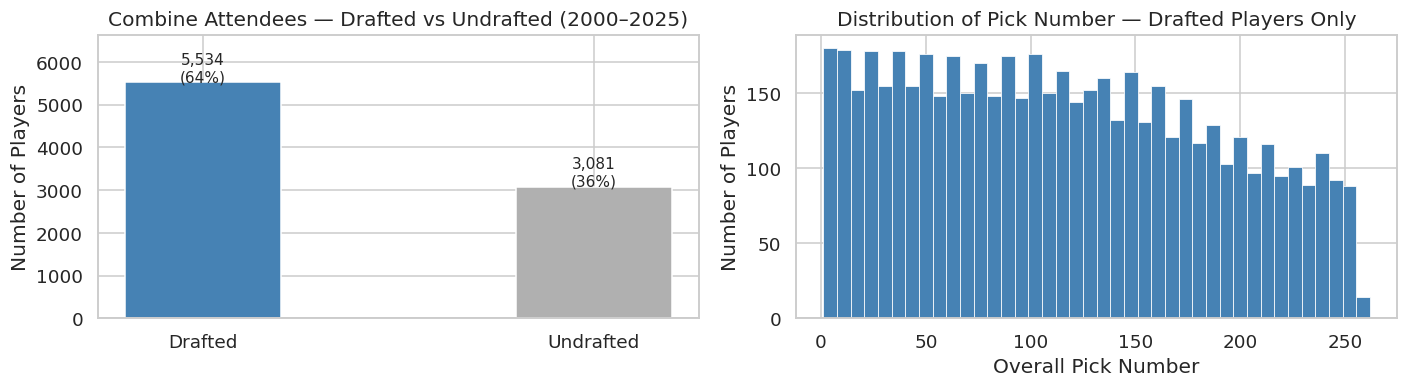

Drafted: 5,534 | Pick range: 1–262
Mean pick: 116 | Median: 110


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left — drafted vs undrafted
labels  = ['Drafted', 'Undrafted']
counts  = [df['is_drafted'].sum(), (df['is_drafted']==0).sum()]
axes[0].bar(labels, counts, color=['steelblue','#b0b0b0'],
            edgecolor='white', width=0.4)
axes[0].set_ylim(0, max(counts) * 1.2)
axes[0].set_ylabel('Number of Players')
axes[0].set_title('Combine Attendees — Drafted vs Undrafted (2000–2025)')
for i, v in enumerate(counts):
    axes[0].text(i, v + 10, f'{v:,}\n({v/sum(counts)*100:.0f}%)',
                 ha='center', fontsize=10)

# Right — pick number distribution among drafted players
drafted = df[df['is_drafted'] == 1]['draft_ovr'].dropna()
axes[1].hist(drafted, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Overall Pick Number')
axes[1].set_ylabel('Number of Players')
axes[1].set_title('Distribution of Pick Number — Drafted Players Only')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('fig_draft_distribution.png', bbox_inches='tight')
plt.show()

print(f"Drafted: {len(drafted):,} | Pick range: {int(drafted.min())}–{int(drafted.max())}")
print(f"Mean pick: {drafted.mean():.0f} | Median: {drafted.median():.0f}")


### 2.3 — Athletic Measurable Distributions

Checking that drill measurements follow roughly normal distributions confirms that median-based imputation is appropriate and that would highlight any missed outlier datapoints.



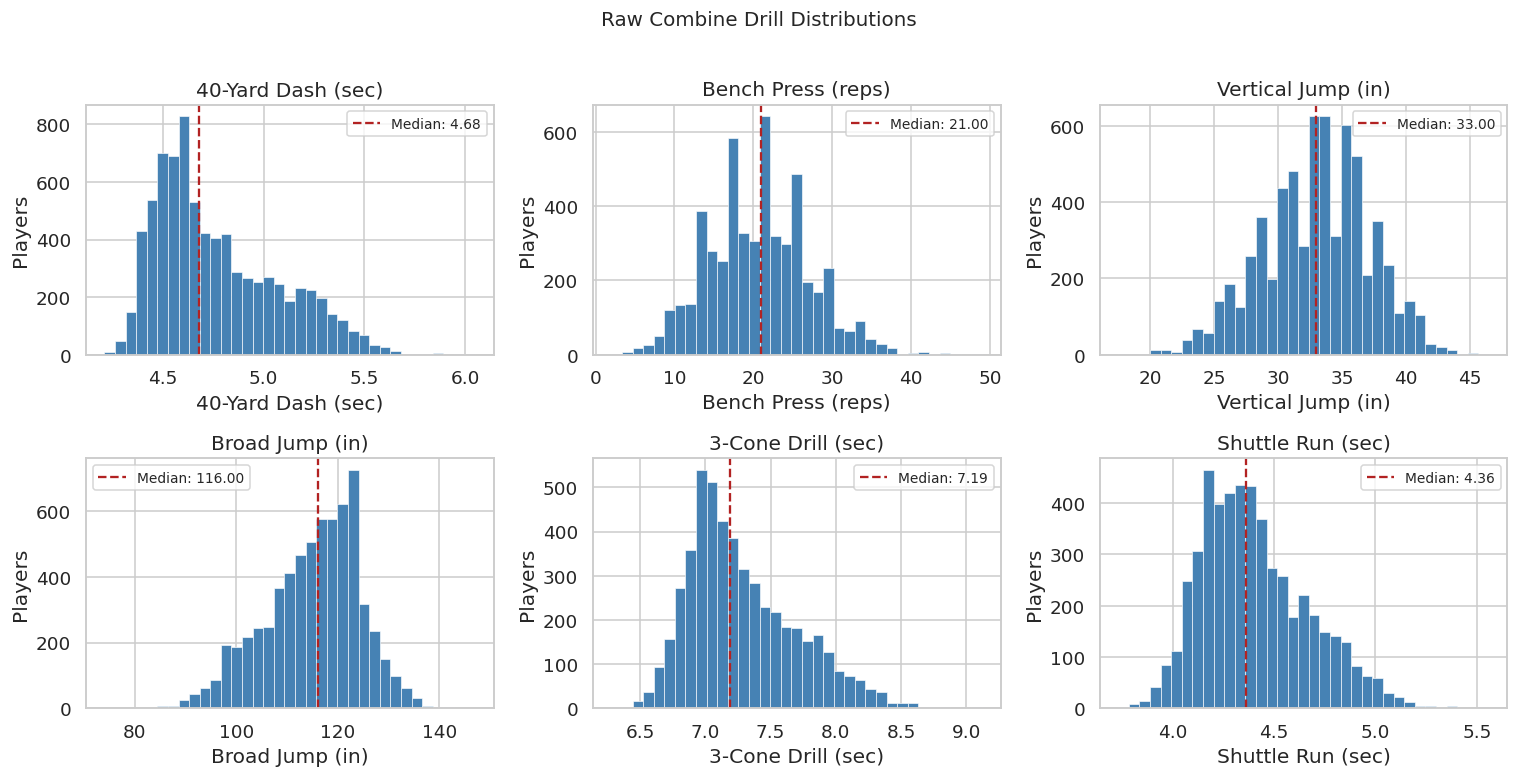

In [11]:
drill_cols = ['forty','bench','vertical','broad_jump','cone','shuttle']
drill_labels = {
    'forty':'40-Yard Dash (sec)','bench':'Bench Press (reps)',
    'vertical':'Vertical Jump (in)','broad_jump':'Broad Jump (in)',
    'cone':'3-Cone Drill (sec)','shuttle':'Shuttle Run (sec)',
}

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(drill_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=35, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].axvline(data.median(), color='firebrick', linestyle='--',
                    linewidth=1.5, label=f'Median: {data.median():.2f}')
    axes[i].set_xlabel(drill_labels[col])
    axes[i].set_ylabel('Players')
    axes[i].set_title(drill_labels[col])
    axes[i].legend(fontsize=9)

plt.suptitle('Raw Combine Drill Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_drill_distributions.png', bbox_inches='tight')
plt.show()


### 2.4 — Do Better Athletes Get Drafted Earlier?

Pearson correlations between each athletic measurable and overall pick number give an initial sense of which combine tests carry the most signal. 


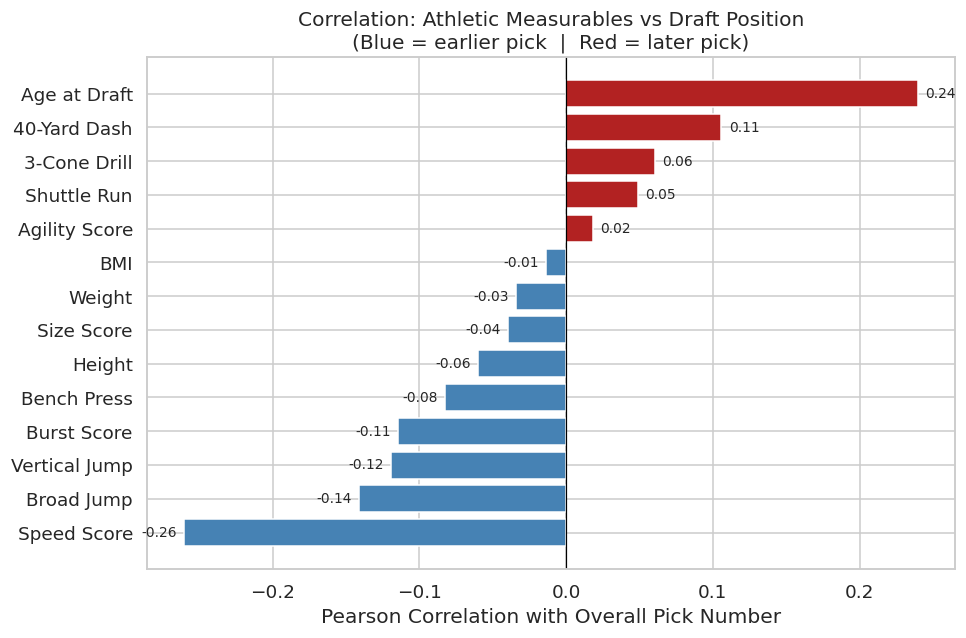

In [12]:
df_drafted = df[df['is_drafted'] == 1].copy()

feature_cols = [
    'forty','bench','vertical','broad_jump','cone','shuttle',
    'speed_score','burst_score','agility_score','bmi','size_score',
    'height_inches','weight','age_at_draft'
]
feature_labels = {
    'forty':'40-Yard Dash','bench':'Bench Press',
    'vertical':'Vertical Jump','broad_jump':'Broad Jump',
    'cone':'3-Cone Drill','shuttle':'Shuttle Run',
    'speed_score':'Speed Score','burst_score':'Burst Score',
    'agility_score':'Agility Score','bmi':'BMI',
    'size_score':'Size Score','height_inches':'Height',
    'weight':'Weight','age_at_draft':'Age at Draft',
}

corr_vals = {}
for col in feature_cols:
    subset = df_drafted[['draft_ovr', col]].dropna()
    if len(subset) > 50:
        corr_vals[col] = subset['draft_ovr'].corr(subset[col])

corr_series = pd.Series(corr_vals).rename(index=feature_labels).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colours = ['steelblue' if v < 0 else 'firebrick' for v in corr_series.values]
bars = ax.barh(corr_series.index, corr_series.values, color=colours, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Overall Pick Number')
ax.set_title('Correlation: Athletic Measurables vs Draft Position\n'
             '(Blue = earlier pick  |  Red = later pick)')

for bar, val in zip(bars, corr_series.values):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_correlations.png', bbox_inches='tight')
plt.show()




### 2.5 — Drafted vs Undrafted: Do Athletic Scores Differ?

Research question 2 is about understanding whether there is meaningful athletic differences between drafted and undrafted players. By comparing the distributions of these groups we get a first sense of whether this may be the case and in what categories to help direct further analysis.


Speed Score                          Drafted: 96.7  |  Undrafted: 88.5
Burst Score                          Drafted: 42.8  |  Undrafted: 41.3
Agility Score (lower = better)       Drafted: 11.1  |  Undrafted: 11.3
Size Score                           Drafted: 18184.8  |  Undrafted: 17658.6


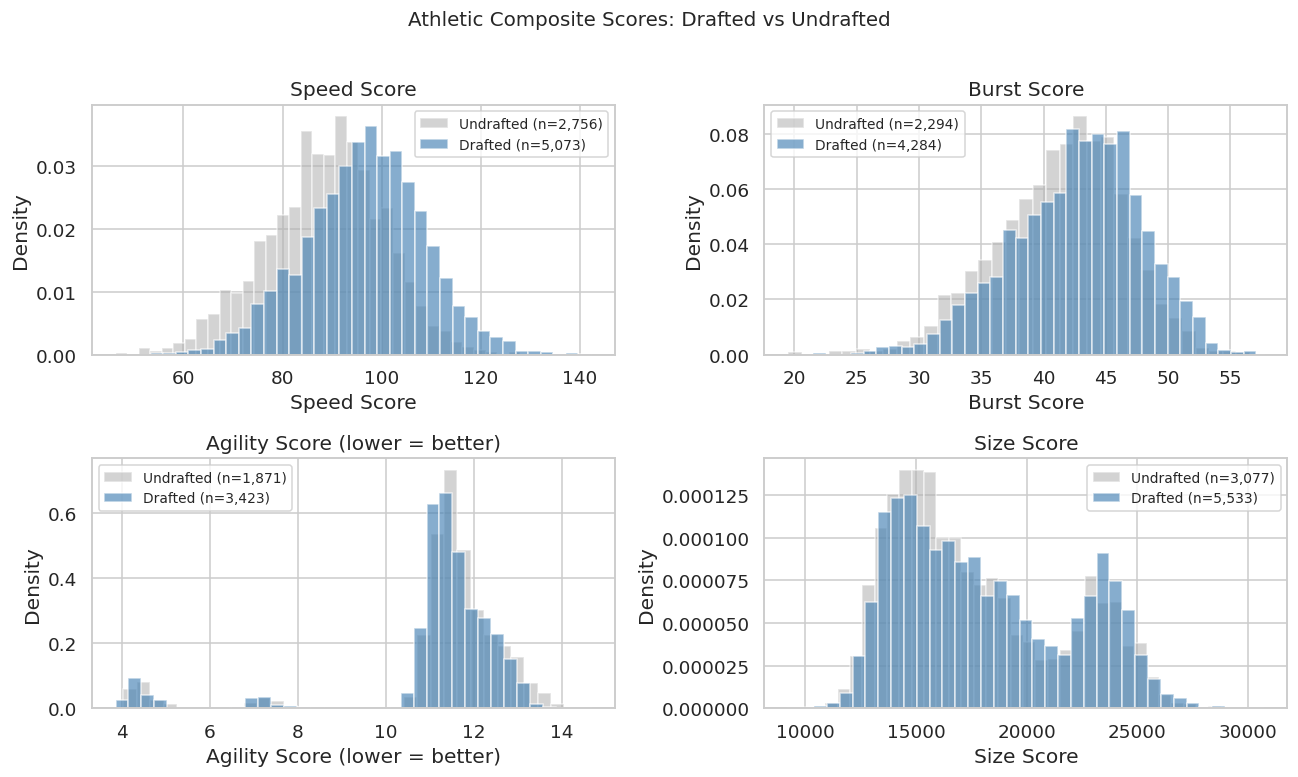

In [13]:
composite_cols   = ['speed_score','burst_score','agility_score','size_score']
composite_labels = {
    'speed_score':'Speed Score','burst_score':'Burst Score',
    'agility_score':'Agility Score (lower = better)','size_score':'Size Score',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.flatten()

for i, col in enumerate(composite_cols):
    d_vals = df[df['is_drafted']==1][col].dropna()
    u_vals = df[df['is_drafted']==0][col].dropna()

    axes[i].hist(u_vals, bins=35, alpha=0.55, color='#b0b0b0',
                 label=f'Undrafted (n={len(u_vals):,})', density=True)
    axes[i].hist(d_vals, bins=35, alpha=0.65, color='steelblue',
                 label=f'Drafted (n={len(d_vals):,})', density=True)
    axes[i].set_xlabel(composite_labels[col])
    axes[i].set_ylabel('Density')
    axes[i].set_title(composite_labels[col])
    axes[i].legend(fontsize=9)
    print(f"{composite_labels[col]:<35}  Drafted: {d_vals.mean():.1f}  |  Undrafted: {u_vals.mean():.1f}")

plt.suptitle('Athletic Composite Scores: Drafted vs Undrafted', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig_drafted_vs_undrafted.png', bbox_inches='tight')
plt.show()


Drafted players score meaningfully better across all four composites. The distributions overlap substantially but the shift is consistent, confirming that the classification task has signal to work with.

### 2.6 — EDA Summary

| Observation | Implication for modelling |
|------------|--------------------------|
| ~35–40% of combine attendees go undrafted | Class imbalance requires oversampling before classification |
| Pick numbers broadly flat across 1–262 | No transformation of the regression target required |
| Athletic correlations modest (±0.10 to ±0.25) | Models will have real but limited predictive power |
| Drafted vs undrafted separation visible in composites | Classification models have genuine signal to learn from |
| High drill missingness (bench 35%, cone 34%) | Position-group median imputation required |




---
## Section 3 — Preprocessing & Modelling

This section covers all preprocessing decisions and builds models for both research questions. 

- **Task A** — Regression: predicting exact pick number (`draft_ovr`)
- **Task B** — Binary classification: predicting drafted vs undrafted (`is_drafted`)



### 3.1 — Load Dataset

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBRegressor, XGBClassifier
from imblearn.over_sampling import RandomOverSampler

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('nfl_combine_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: 8,615 rows x 27 columns


### 3.2 — Preprocessing

Depending on the datapoint I have applied different approaches to dealing with missing data. 

**Missing value imputation:** Position-group medians are used for raw drill columns. A missing bench press for a quarterback should be filled with the QB median rather than the overall median. Overall medians are used for composite scores and physical measurements.

**Encoding:** Categorical columns (`pos_group`, `conf_tier`, `era`) are one-hot encoded using `pd.get_dummies()` with `drop_first=True`. Dropping one category per feature avoids the dummy variable trap.

**Feature sets:** High collinearity exists between raw drill columns and the composite scores derived from them (e.g. `forty` and `speed_score`). To avoid inflating variance in linear models, composite features only are used for Linear Regression and Lasso. The full feature set is used for Random Forest and XGBoost, which handle collinearity well and benefit from the additional granularity.

**Scaling:** StandardScaler is applied to the composite feature set for linear models. Scaling is fitted on training data only and applied to test data to avoid leaking test info into the training process. 

**Class imbalance (RandomOverSampler):** The classification dataset is approximately 65% drafted / 35% undrafted. Without correction, a model can achieve high accuracy simply by predicting the majority class every time. `RandomOverSampler` ensures both classes are equally represented in the training data, forcing the model to learn what distinguishes the two groups. 


In [15]:
df_model = df.copy()

# Position-group median imputation for drill columns
drill_cols = ['forty','bench','vertical','broad_jump','cone','shuttle']
for col in drill_cols:
    pos_med = df_model.groupby('pos_group')[col].transform('median')
    df_model[col] = df_model[col].fillna(pos_med).fillna(df_model[col].median())

# Overall median imputation for composites and physical measurements
for col in ['speed_score','burst_score','agility_score','bmi','size_score',
            'height_inches','weight','age_at_draft']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Categorical imputation and one-hot encoding
CAT_COLS = ['pos_group','conf_tier','era']
for col in CAT_COLS:
    df_model[col] = df_model[col].fillna('Unknown')

df_enc = pd.get_dummies(df_model, columns=CAT_COLS, drop_first=True, dtype=int)
enc_cats = [c for c in df_enc.columns
            if any(c.startswith(f'{cat}_') for cat in CAT_COLS)]

# Feature sets
COMPOSITE_FEATS = [
    'height_inches','weight','bench',
    'speed_score','burst_score','agility_score','bmi','size_score',
    'age_at_draft','is_skill','is_blue_blood','is_sec',
] + enc_cats

FULL_FEATS = [
    'height_inches','weight','forty','bench','vertical','broad_jump',
    'cone','shuttle','speed_score','burst_score','agility_score',
    'bmi','size_score','age_at_draft','is_skill','is_blue_blood','is_sec',
] + enc_cats

print(f"Composite feature set: {len(COMPOSITE_FEATS)} features")
print(f"Full feature set:      {len(FULL_FEATS)} features")

nulls = df_enc[FULL_FEATS].isnull().sum().sum()
print(f"Remaining nulls in feature columns: {nulls}")


Composite feature set: 26 features
Full feature set:      31 features
Remaining nulls in feature columns: 0


### 3.3 — Train/Test Splits & Oversampling

Two separate splits are created, one per task. The regression split uses drafted players only since undrafted players have no pick number to predict.


In [16]:
# Task B — classification (all players) 
X_all = df_enc[FULL_FEATS]
y_cls = df_enc['is_drafted']

X_tr, X_te, y_tr_cls, y_te_cls = train_test_split(
    X_all, y_cls, test_size=0.2, random_state=22, stratify=y_cls)

ros = RandomOverSampler(random_state=22)
X_tr_ros, y_tr_ros = ros.fit_resample(X_tr, y_tr_cls)

print(f"Classification — original train: {len(X_tr):,} | after oversampling: {len(X_tr_ros):,}")
print(f"Class balance after oversampling:")
print(pd.Series(y_tr_ros).value_counts(normalize=True).round(3).to_string())

# Task A — regression (drafted players only)
df_reg  = df_enc[df_enc['is_drafted'] == 1].copy()
X_reg   = df_reg[FULL_FEATS]
y_reg   = df_reg['draft_ovr']

X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=22)

print(f"\nRegression — Train: {len(X_tr_reg):,} | Test: {len(X_te_reg):,}")

# Composite subsets (for linear models)
X_tr_comp  = X_tr[COMPOSITE_FEATS]
X_te_comp  = X_te[COMPOSITE_FEATS]
X_tr_rc    = X_tr_reg[COMPOSITE_FEATS]
X_te_rc    = X_te_reg[COMPOSITE_FEATS]

# Composite subsets post-oversampling (for logistic regression)
X_tr_ros_comp = X_tr_ros[COMPOSITE_FEATS]

# Scale composite features 
sc_cls = StandardScaler()
X_tr_comp_s     = pd.DataFrame(sc_cls.fit_transform(X_tr_comp),
                                columns=COMPOSITE_FEATS, index=X_tr_comp.index)
X_te_comp_s     = pd.DataFrame(sc_cls.transform(X_te_comp),
                                columns=COMPOSITE_FEATS, index=X_te_comp.index)
X_tr_ros_comp_s = pd.DataFrame(sc_cls.transform(X_tr_ros_comp),
                                columns=COMPOSITE_FEATS, index=X_tr_ros_comp.index)

sc_reg = StandardScaler()
X_tr_rc_s = pd.DataFrame(sc_reg.fit_transform(X_tr_rc),
                           columns=COMPOSITE_FEATS, index=X_tr_rc.index)
X_te_rc_s = pd.DataFrame(sc_reg.transform(X_te_rc),
                           columns=COMPOSITE_FEATS, index=X_te_rc.index)

# Results stores
results_reg = {}
results_cls = {}
cv_results  = {}


Classification — original train: 6,892 | after oversampling: 8,854
Class balance after oversampling:
is_drafted
1    0.5
0    0.5

Regression — Train: 4,427 | Test: 1,107


### 3.4 — K-Fold Cross-Validation

Before evaluating models on the test set, 5-fold cross-validation is run on the training data to give an estimate of how stable each model's performance is across different subsets of the training data.

In [17]:

# Regression CV
kf = KFold(n_splits=5, shuffle=True, random_state=22)

reg_models_cv = {
    'Linear Regression': (LinearRegression(), X_tr_rc_s),
    'Lasso':             (Lasso(alpha=1.0, max_iter=5000, random_state=22), X_tr_rc_s),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, max_depth=8,
                          min_samples_leaf=10, random_state=22, n_jobs=-1), X_tr_reg),
    'XGBoost':           (XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=22, verbosity=0), X_tr_reg),
}

print("\nREGRESSION — 5-Fold CV (MAE, lower is better):")
for name, (model, X_cv) in reg_models_cv.items():
    scores = cross_val_score(model, X_cv, y_tr_reg,
                             cv=kf, scoring='neg_mean_absolute_error')
    mae_mean = -scores.mean()
    mae_std  = scores.std()
    cv_results[f'CV {name} (reg)'] = {'CV MAE Mean': round(mae_mean,1),
                                       'CV MAE Std': round(mae_std,1)}
    print(f"  {name:<22} MAE: {mae_mean:.1f} ± {mae_std:.1f} picks")

# Classification CV 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=22)

cls_models_cv = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced',
                             max_iter=1000, random_state=22), X_tr_comp_s),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, max_depth=8,
                             class_weight='balanced',
                             random_state=22, n_jobs=-1), X_tr),
    'XGBoost':             (XGBClassifier(n_estimators=300, max_depth=5,
                             learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                             random_state=22, verbosity=0,
                             eval_metric='logloss'), X_tr),
}

print("\nCLASSIFICATION — 5-Fold CV (ROC-AUC, higher is better):")
for name, (model, X_cv) in cls_models_cv.items():
    scores = cross_val_score(model, X_cv, y_tr_cls,
                             cv=skf, scoring='roc_auc')
    cv_results[f'CV {name} (cls)'] = {'CV AUC Mean': round(scores.mean(),3),
                                       'CV AUC Std': round(scores.std(),3)}
    print(f"  {name:<22} AUC: {scores.mean():.3f} ± {scores.std():.3f}")

print("\nCross-validation complete. Proceeding to hold-out test evaluation.")



REGRESSION — 5-Fold CV (MAE, lower is better):
  Linear Regression      MAE: 55.2 ± 1.5 picks
  Lasso                  MAE: 55.8 ± 1.5 picks
  Random Forest          MAE: 55.0 ± 1.5 picks
  XGBoost                MAE: 55.0 ± 1.6 picks

CLASSIFICATION — 5-Fold CV (ROC-AUC, higher is better):
  Logistic Regression    AUC: 0.788 ± 0.009
  Random Forest          AUC: 0.896 ± 0.003
  XGBoost                AUC: 0.897 ± 0.003

Cross-validation complete. Proceeding to hold-out test evaluation.


---
### 3.5 — Task A: Predicting Draft Pick Number (`draft_ovr`)


5 Models are tested and compared for effectiveness:

The Dummy Regressor establishes the baseline of score that any model needs to beat to be worth using. Linear Regression tests whether a simple linear relationship is present. Lasso adds L1 regularisation, Random Forest and XGBoost capture non-linear patterns and feature interactions that linear models cannot.


**Evaluation metrics:**
- **MAE** — average number of picks the prediction is off by. 
- **R²** — proportion of variance in pick number explained by the model.


In [18]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    results_reg[name] = {'MAE': round(mae,1), 'RMSE': round(rmse,1), 'R2': round(r2,3)}
    print(f"  MAE: {mae:.1f} picks  |  RMSE: {rmse:.1f}  |  R2: {r2:.3f}")

# Dummy Regressor (baseline)
print("DUMMY REGRESSOR (predicts mean pick number every time)")
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_tr_rc_s, y_tr_reg)
reg_metrics('Dummy', y_te_reg, dummy_reg.predict(X_te_rc_s))

# Linear Regression
print("\nLINEAR REGRESSION")
lr = LinearRegression()
lr.fit(X_tr_rc_s, y_tr_reg)
reg_metrics('Linear Regression', y_te_reg, lr.predict(X_te_rc_s))

# Lasso Regression
print("\nLASSO REGRESSION")
# alpha=1.0 is the default regularisation strength — the L1 penalty shrinks
# redundant coefficients to zero, a practical response to the collinearity
# between raw drills and their derived composite scores
lasso = Lasso(alpha=1.0, max_iter=5000, random_state=22)
lasso.fit(X_tr_rc_s, y_tr_reg)
reg_metrics('Lasso', y_te_reg, lasso.predict(X_te_rc_s))
zeroed = (np.abs(lasso.coef_) < 1e-6).sum()
print(f"  Lasso zeroed out {zeroed}/{len(COMPOSITE_FEATS)} features")

# Random Forest
print("\nRANDOM FOREST")
# n_estimators=200 balances accuracy and runtime
# max_depth=8 and min_samples_leaf=10 prevent overfitting
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8,
                                min_samples_leaf=10, random_state=22, n_jobs=-1)
rf_reg.fit(X_tr_reg, y_tr_reg)
reg_metrics('Random Forest', y_te_reg, rf_reg.predict(X_te_reg))

# XGBoost
print("\nXGBOOST")
# learning_rate=0.05 with 300 trees is more stable than a high learning
# rate with fewer trees — a standard configuration for gradient boosting
xgb_reg = XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=22, verbosity=0)
xgb_reg.fit(X_tr_reg, y_tr_reg)
reg_metrics('XGBoost', y_te_reg, xgb_reg.predict(X_te_reg))


DUMMY REGRESSOR (predicts mean pick number every time)
  MAE: 59.0 picks  |  RMSE: 69.4  |  R2: -0.000

LINEAR REGRESSION
  MAE: 52.6 picks  |  RMSE: 63.1  |  R2: 0.174

LASSO REGRESSION
  MAE: 53.3 picks  |  RMSE: 63.4  |  R2: 0.165
  Lasso zeroed out 8/26 features

RANDOM FOREST
  MAE: 51.7 picks  |  RMSE: 61.8  |  R2: 0.206

XGBOOST
  MAE: 51.0 picks  |  RMSE: 61.4  |  R2: 0.218


### 3.6 — Regression Results Comparison


In [19]:
reg_df = pd.DataFrame(results_reg).T.sort_values('MAE')
print("REGRESSION — Test Set Results (sorted by MAE, lower is better)")
print(reg_df.to_string())
print(f"\nBaseline (Dummy) R2: {results_reg['Dummy']['R2']} — all models above this add value")
print(f"Best model: {reg_df.index[0]} (MAE = {reg_df['MAE'].iloc[0]} picks)")


REGRESSION — Test Set Results (sorted by MAE, lower is better)
                    MAE  RMSE     R2
XGBoost            51.0  61.4  0.218
Random Forest      51.7  61.8  0.206
Linear Regression  52.6  63.1  0.174
Lasso              53.3  63.4  0.165
Dummy              59.0  69.4 -0.000

Baseline (Dummy) R2: -0.0 — all models above this add value
Best model: XGBoost (MAE = 51.0 picks)


---
### 3.8 — Task B: Predicting Drafted vs Undrafted (`is_drafted`)

The same modelling progression — Dummy → linear → ensemble — is applied to the binary classification task. Models are trained on the oversampled training set and evaluated on the original test set distribution.

**Evaluation metrics:**
- **ROC-AUC** — measures how well the model ranks drafted players above undrafted ones regardless of the decision threshold. 0.5 = random guessing; 1.0 = perfect. This is the primary metric because it is robust to class imbalance.
- **F1 Score** — balances precision and recall. More meaningful than accuracy when the two classes are not equally represented.

**Dummy Classifier baseline:** Predicts the majority class (drafted) for every player. This achieves high accuracy simply by exploiting the class imbalance — any useful model must exceed this benchmark on the more informative metrics.


In [20]:
def cls_metrics(name, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else None
    entry = {'Accuracy': round(acc,3), 'F1': round(f1,3)}
    if auc: entry['ROC-AUC'] = round(auc,3)
    results_cls[name] = entry
    auc_str = f"  ROC-AUC: {auc:.3f}" if auc else ""
    print(f"  Accuracy: {acc:.3f}  |  F1: {f1:.3f}{auc_str}")

# Dummy Classifier (baseline)
print("DUMMY CLASSIFIER (predicts majority class — drafted — every time)")
dummy_cls = DummyClassifier(strategy='most_frequent', random_state=22)
dummy_cls.fit(X_tr, y_tr_cls)
cls_metrics('Dummy', y_te_cls, dummy_cls.predict(X_te))

# Logistic Regression 
print("\nLOGISTIC REGRESSION (trained on oversampled data)")
log_cls = LogisticRegression(max_iter=1000, random_state=22)
log_cls.fit(X_tr_ros_comp_s, y_tr_ros)
cls_metrics('Logistic Regression', y_te_cls,
            log_cls.predict(X_te_comp_s),
            log_cls.predict_proba(X_te_comp_s)[:,1])

# Random Forest
print("\nRANDOM FOREST (trained on oversampled data)")
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=8,
                                 random_state=22, n_jobs=-1)
rf_cls.fit(X_tr_ros, y_tr_ros)
cls_metrics('Random Forest', y_te_cls,
            rf_cls.predict(X_te),
            rf_cls.predict_proba(X_te)[:,1])

# XGBoost
print("\nXGBOOST (trained on oversampled data)")
xgb_cls = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                         subsample=0.8, colsample_bytree=0.8,
                         random_state=22, verbosity=0, eval_metric='logloss')
xgb_cls.fit(X_tr_ros, y_tr_ros)
cls_metrics('XGBoost', y_te_cls,
            xgb_cls.predict(X_te),
            xgb_cls.predict_proba(X_te)[:,1])


DUMMY CLASSIFIER (predicts majority class — drafted — every time)
  Accuracy: 0.642  |  F1: 0.782

LOGISTIC REGRESSION (trained on oversampled data)
  Accuracy: 0.690  |  F1: 0.735  ROC-AUC: 0.771

RANDOM FOREST (trained on oversampled data)
  Accuracy: 0.786  |  F1: 0.814  ROC-AUC: 0.887

XGBOOST (trained on oversampled data)
  Accuracy: 0.795  |  F1: 0.824  ROC-AUC: 0.889


### 3.9 — Classification Results Comparison


In [21]:
cls_df = pd.DataFrame(results_cls).T.sort_values('ROC-AUC', ascending=False)
print("CLASSIFICATION — Test Set Results (sorted by ROC-AUC, higher is better)")

print(cls_df.to_string())
print(f"\nDummy ROC-AUC: 0.500 — random guessing benchmark")
print(f"Best model: {cls_df.index[0]} (ROC-AUC = {cls_df['ROC-AUC'].iloc[0]})")


CLASSIFICATION — Test Set Results (sorted by ROC-AUC, higher is better)
                     Accuracy     F1  ROC-AUC
XGBoost                 0.795  0.824    0.889
Random Forest           0.786  0.814    0.887
Logistic Regression     0.690  0.735    0.771
Dummy                   0.642  0.782      NaN

Dummy ROC-AUC: 0.500 — random guessing benchmark
Best model: XGBoost (ROC-AUC = 0.889)


The step up from Logistic Regression to tree-based models reflects non-linear athletic thresholds for getting drafted that a linear decision boundary cannot capture. All three models significantly outperform the dummy baseline on ROC-AUC and F1, confirming that combine measurables contain genuine signal about whether a player gets drafted. Note that accuracy alone is not a reliable metric here — the dummy classifier achieves high accuracy simply by predicting "drafted" for every player.


### 3.10 — Confusion Matrix

A confusion matrix shows the breakdown of correct and incorrect classifications for each model. The comparison between Logistic Regression and XGBoost illustrates the improvement from the linear to the tree-based approach.


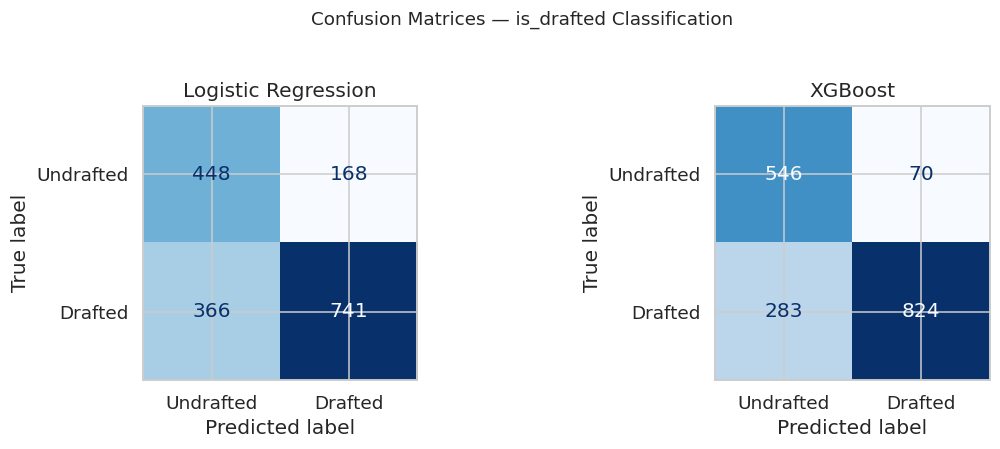

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (name, model, X_test_data) in zip(axes, [
    ('Logistic Regression', log_cls, X_te_comp_s),
    ('XGBoost',             xgb_cls, X_te),
]):
    cm = confusion_matrix(y_te_cls, model.predict(X_test_data))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Undrafted','Drafted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices — is_drafted Classification', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', bbox_inches='tight')
plt.show()


The confusion matrix highlights the trade-off between correctly identifying undrafted players (true negatives) and drafted players (true positives). Both models avoid the degenerate outcome of the dummy classifier, which would show all predictions in a single column.


---
## Section 4 — Conclusions

### 4.1 — Summary of Results


In [23]:
print("=" * 60)
print("TASK A — REGRESSION (draft_ovr)")
print("=" * 60)
print(pd.DataFrame(results_reg).T.sort_values('MAE').to_string())

print("\n" + "=" * 60)
print("TASK B — CLASSIFICATION (is_drafted)")
print("=" * 60)
print(pd.DataFrame(results_cls).T.sort_values('ROC-AUC', ascending=False).to_string())

print("\n" + "=" * 60)
print("K-FOLD CROSS-VALIDATION SUMMARY")
print("=" * 60)
print(pd.DataFrame(cv_results).T.to_string())


TASK A — REGRESSION (draft_ovr)
                    MAE  RMSE     R2
XGBoost            51.0  61.4  0.218
Random Forest      51.7  61.8  0.206
Linear Regression  52.6  63.1  0.174
Lasso              53.3  63.4  0.165
Dummy              59.0  69.4 -0.000

TASK B — CLASSIFICATION (is_drafted)
                     Accuracy     F1  ROC-AUC
XGBoost                 0.795  0.824    0.889
Random Forest           0.786  0.814    0.887
Logistic Regression     0.690  0.735    0.771
Dummy                   0.642  0.782      NaN

K-FOLD CROSS-VALIDATION SUMMARY
                              CV MAE Mean  CV MAE Std  CV AUC Mean  CV AUC Std
CV Linear Regression (reg)           55.2         1.5          NaN         NaN
CV Lasso (reg)                       55.8         1.5          NaN         NaN
CV Random Forest (reg)               55.0         1.5          NaN         NaN
CV XGBoost (reg)                     55.0         1.6          NaN         NaN
CV Logistic Regression (cls)          NaN         